In [2]:
import numpy as np
import matplotlib.pyplot as plt

import os
import matplotlib.animation as animation

from relu2D_main import *

In [3]:
### setup parameters
L = 31
N = L
dt = 0.0001
Nstep_init = 1 * 10 ** 3
Nstep = 2 * 10 ** 3
npf = 5

# Network type
ntype = 'relu_gaussian'

# Network parameters
J0 = np.array([[1, -4], [2, -2]])
K = 10 ** 2
tau = np.array([.01, .01])
u = np.array([10, 0])
sigma = 0.05 * np.array([1, np.sqrt(2)])
J2 = np.array([[0.454, -0.825], [0.908, -0.412]])
J3 = np.array([[12, -23], [19, -9]])

# Initial state
r0 = -np.linalg.inv(J0) @ u
re0 = r0[0] + 0.05 * np.random.rand(L, L)
ri0 = r0[1] + 0.08 * np.random.rand(L, L)

In [4]:
### call functions for simulation
# Time and space axes
tt = dt * npf * np.arange(1, Nstep // npf + 1)
xx = np.arange(1, L + 1) / L
yy = np.arange(1, L + 1) / L

# Run simulation
re_all, ri_all = relu2D(L, dt, Nstep_init, Nstep, npf, ntype, K, tau, u, J0, sigma, J2, J3, re0, ri0)

initializing simulation... 0.000.0.010.0.020.0.030.0.040.0.050.0.060.0.070.0.080.0.090.0.100.0.110.0.120.0.130.0.140.0.150.0.160.0.170.0.180.0.190.0.200.0.210.0.220.0.230.0.240.0.250.0.260.0.270.0.280.0.290.0.300.0.310.0.320.0.330.0.340.0.350.0.360.0.370.0.380.0.390.0.400.0.410.0.420.0.430.0.440.0.450.0.460.0.470.0.480.0.490.0.500.0.510.0.520.0.530.0.540.0.550.0.560.0.570.0.580.0.590.0.600.0.610.0.620.0.630.0.640.0.650.0.660.0.670.0.680.0.690.0.700.0.710.0.720.0.730.0.740.0.750.0.760.0.770.0.780.0.790.0.800.0.810.0.820.0.830.0.840.0.850.0.860.0.870.0.880.0.890.0.900.0.910.0.920.0.930.0.940.0.950.0.960.0.970.0.980.0.991.0
running simulation... 0.000.000.000.0.010.010.010.0.020.020.020.0.030.030.030.0.040.040.040.0.050.050.050.0.060.060.060.0.070.070.070.0.080.080.080.0.090.090.090.0.100.100.100.0.110.110.110.0.120.120.120.0.130.130.130.0.140.140.140.0.150.150.150.0.160.160.160.0.170.170.170.0.180.180.180.0.190.190.190.0.200.200.200.0.210.210.210.0.220.220.220.0.230.230.230.0.240.240.240

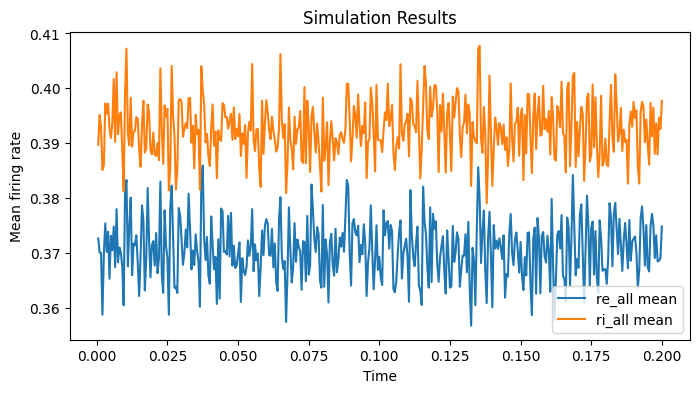

In [5]:
### visualize results
plt.figure(figsize=(8, 4))
plt.plot(tt, re_all.mean(axis=(0, 1)), label='re_all mean')
plt.plot(tt, ri_all.mean(axis=(0, 1)), label='ri_all mean')
plt.xlabel('Time')
plt.ylabel('Mean firing rate')
plt.legend()
plt.title('Simulation Results')
plt.show()


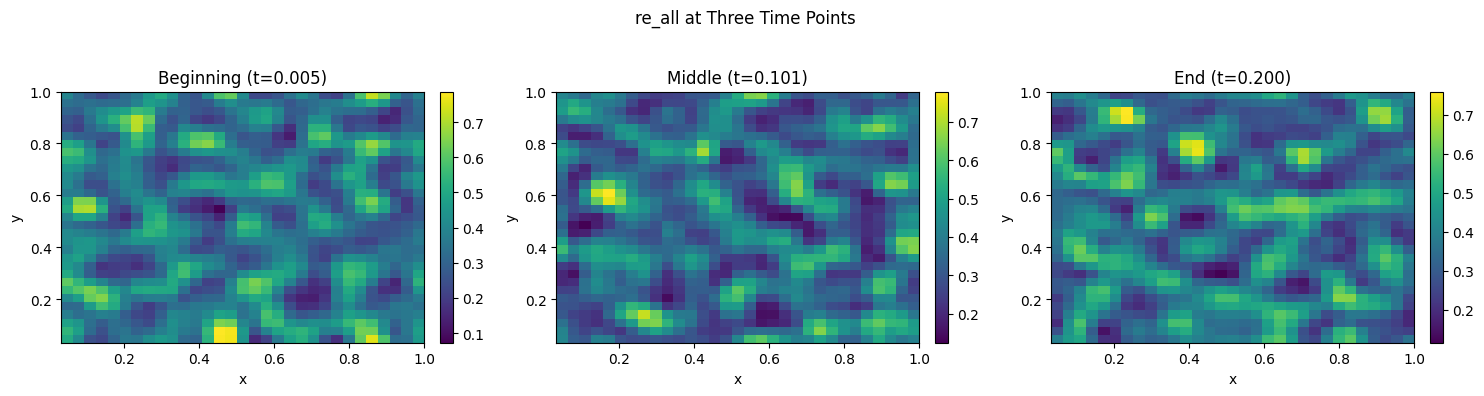

In [8]:
# Plot three time points of re_all
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
time_indices = [10, len(tt) // 2, -1]
titles = ['Beginning', 'Middle', 'End']

for i, idx in enumerate(time_indices):
    im = axs[i].imshow(re_all[:, :, idx], aspect='auto', origin='lower', extent=[xx[0], xx[-1], yy[0], yy[-1]])
    axs[i].set_title(f"{titles[i]} (t={tt[idx]:.3f})")
    axs[i].set_xlabel('x')
    axs[i].set_ylabel('y')
    fig.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)

plt.suptitle('re_all at Three Time Points')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [6]:
### make driven pattern and target output

In [7]:
### train the network